In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import skfda 

from skfda.representation.basis import BSplineBasis, FourierBasis
from skfda.preprocessing.smoothing import BasisSmoother
from skfda.preprocessing.dim_reduction import FPCA
from sklearn.decomposition import PCA

from statsmodels.tsa.api import VAR

### Simulation (AdaFNN)

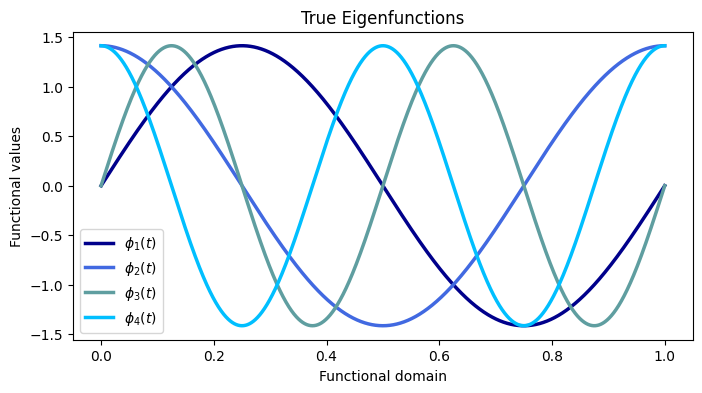

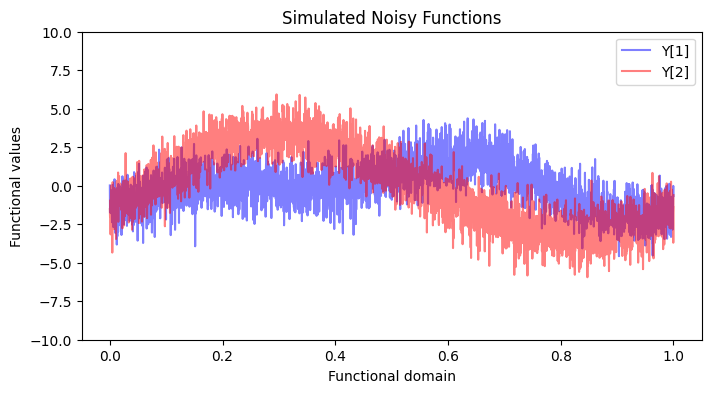

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Set seed for reproducibility
np.random.seed(5242022)

# Settings
n = 50         # number of subjects
p = 3000       # dimension of the data (number of time points)
t = np.linspace(0, 1, p)  # regular grid on [0, 1]
K = 4          # number of eigenfunctions
sigma =  1     # standard deviation of the noise
lambda_true = np.array([1, 0.5, 0.5**2, 0.5**3])  # eigenvalues

# True eigenfunctions (shape: p x K)
phi = np.sqrt(2) * np.column_stack([
    np.sin(2 * np.pi * t),
    np.cos(2 * np.pi * t),
    np.sin(4 * np.pi * t),
    np.cos(4 * np.pi * t)
])

# Plot the true eigenfunctions
colors = ["darkblue", "royalblue", "cadetblue", "deepskyblue"]
plt.figure(figsize=(8, 4))
for i in range(K):
    plt.plot(t, phi[:, i], lw=2.5, color=colors[i], label=fr'$\phi_{i+1}(t)$')
plt.xlabel("Functional domain")
plt.ylabel("Functional values")
plt.title("True Eigenfunctions")
plt.legend()
plt.grid(False)
plt.show()

# Generate random scores: N(0, lambda_k)
xi = np.random.randn(n, K) @ np.diag(np.sqrt(lambda_true))  # (n x K)
S = xi @ phi.T  # Signal without noise, shape: (n x p)

# Add Gaussian noise
Y = S + sigma * np.random.randn(n, p)

# Plot the first two simulated functions
plt.figure(figsize=(8, 4))
plt.plot(t, Y[0], label="Y[1]", color=(0, 0, 1, 0.5))  # Blue
plt.plot(t, Y[1], label="Y[2]", color=(1, 0, 0, 0.5))  # Red
plt.xlabel("Functional domain")
plt.ylabel("Functional values")
plt.ylim(-10, 10)
plt.title("Simulated Noisy Functions")
plt.legend()
plt.grid(False)
plt.show()


In [3]:
idx = int(p * 0.5)

y_true = S[:, -idx:]

X = Y[:, :-idx]
y = Y[:, -idx:]


X.shape, y.shape

((50, 1500), (50, 1500))

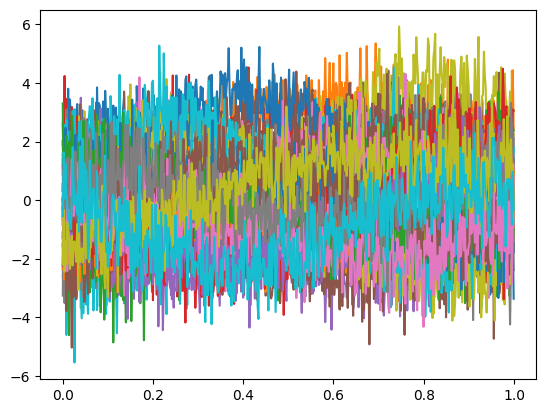

In [4]:

X_fd = skfda.FDataGrid(
    data_matrix=X,
    grid_points=np.arange(0,1, 1/(p-idx)),
)


y_fd = skfda.FDataGrid(
    data_matrix=y,
    grid_points=np.arange(0,1, 1/(idx)),
)


X_fd.plot()
plt.show()

In [5]:
sep = int(n * 0.2)

train_fd = X_fd[:-sep] 
y_train = y_fd[:-sep]

test_fd = X_fd[-sep:]
y_test = y_fd[-sep:]
y_true_test = y_true[-sep:]

In [6]:
(y_true_test - y_test.data_matrix.squeeze()).sum()

-10.924967611567372

### PCA and FPCA compnents 

Explained var FPCA: 0.997056825749506
Explained var PCA: 0.6770100236394604


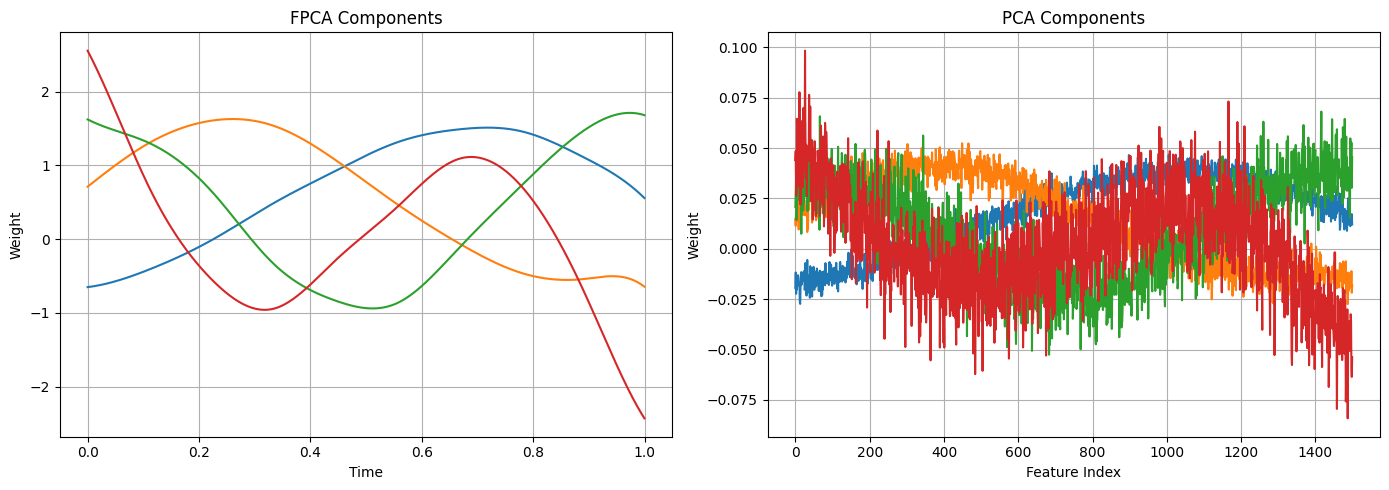

In [7]:
def fit_fpca(train_fd, n_components=4, n_basis=20, order=9):
    
    basis = BSplineBasis(n_basis=12)  
    smoother = BasisSmoother(basis)
    fd_smooth = smoother.fit_transform(train_fd)

    fpca = FPCA(n_components=n_components)
    fpca.fit(fd_smooth)
    scores = fpca.transform(fd_smooth)
    
    return fpca, scores

def fit_pca(train_fd, n_components=4):
    
    data = train_fd.data_matrix.squeeze()
    pca = PCA(n_components=n_components)
    pca.fit(data)
    scores = pca.transform(data)
    
    return pca, scores

def plot_components(fpca, pca):

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    eval_points = fpca.components_[0].grid_points[0]
    for i in range(fpca.n_components):
        values = fpca.components_[i](eval_points)
        axs[0].plot(eval_points, values[0])
    axs[0].set_title("FPCA Components")
    axs[0].set_xlabel("Time")
    axs[0].set_ylabel("Weight")
    axs[0].grid(True)


    for i, component in enumerate(pca.components_):
        axs[1].plot(component)
    axs[1].set_title("PCA Components")
    axs[1].set_xlabel("Feature Index")
    axs[1].set_ylabel("Weight")
    axs[1].grid(True)
    
    plt.tight_layout()
    plt.show()


fpca_model, fpca_scores_df = fit_fpca(train_fd)
pca_model, pca_scores_df = fit_pca(train_fd)

print("Explained var FPCA:", fpca_model.explained_variance_ratio_.sum())
print("Explained var PCA:", pca_model.explained_variance_ratio_.sum())

plot_components(fpca_model, pca_model)


In [8]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)


pca_scores = pca_model.transform(train_fd.data_matrix.squeeze())
y_pca_scores = pca_model.transform(y_train.data_matrix.squeeze())

ols = LinearRegression().fit(pca_scores, y_pca_scores)

pca_input_scores = pca_model.transform(test_fd.data_matrix.squeeze())

y_pred_pca_scores = ols.predict(pca_input_scores)
y_preds_pca = pca_model.inverse_transform(y_pred_pca_scores)

r2   = r2_score(y_test.data_matrix.squeeze(), y_preds_pca)
mae  = mean_absolute_error(y_test.data_matrix.squeeze(), y_preds_pca)
mse = mean_squared_error(y_test.data_matrix.squeeze(), y_preds_pca)  
mape = mean_absolute_percentage_error(y_test.data_matrix.squeeze(), y_preds_pca)

print(f"PCA test metrics")
print(f"  R²     = {r2:.4f}")
print(f"  MAE    = {mae:.4f}")
print(f"  MSE    = {mse:.4f}")


PCA test metrics
  R²     = 0.3290
  MAE    = 0.8689
  MSE    = 1.1796


In [9]:
fpca_scores = fpca_model.transform(train_fd)
y_fpca_scores = fpca_model.transform(y_train)

ols = LinearRegression().fit(fpca_scores, y_fpca_scores)

fpca_input_scores = fpca_model.transform(test_fd)

y_pred_fpca_scores = ols.predict(fpca_input_scores)
y_preds_fpca = fpca_model.inverse_transform(y_pred_fpca_scores)


r2   = r2_score(y_test.data_matrix.squeeze(), y_preds_fpca.data_matrix.squeeze())
mae  = mean_absolute_error(y_test.data_matrix.squeeze(), y_preds_fpca.data_matrix.squeeze())
mse = mean_squared_error(y_test.data_matrix.squeeze(), y_preds_fpca.data_matrix.squeeze())  
mape = mean_absolute_percentage_error(y_test.data_matrix.squeeze(), y_preds_fpca.data_matrix.squeeze())

print(f"FPCA test metrics")
print(f"  R²     = {r2:.4f}")
print(f"  MAE    = {mae:.4f}")
print(f"  MSE    = {mse:.4f}")


FPCA test metrics
  R²     = 0.3959
  MAE    = 0.8053
  MSE    = 1.0116


In [10]:
(fpca_scores - y_fpca_scores).sum()

20.38311319913317

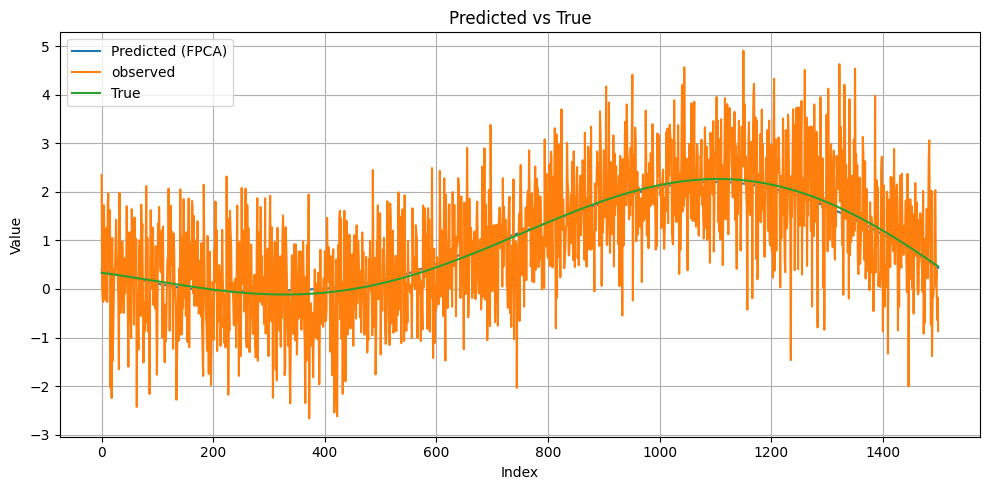

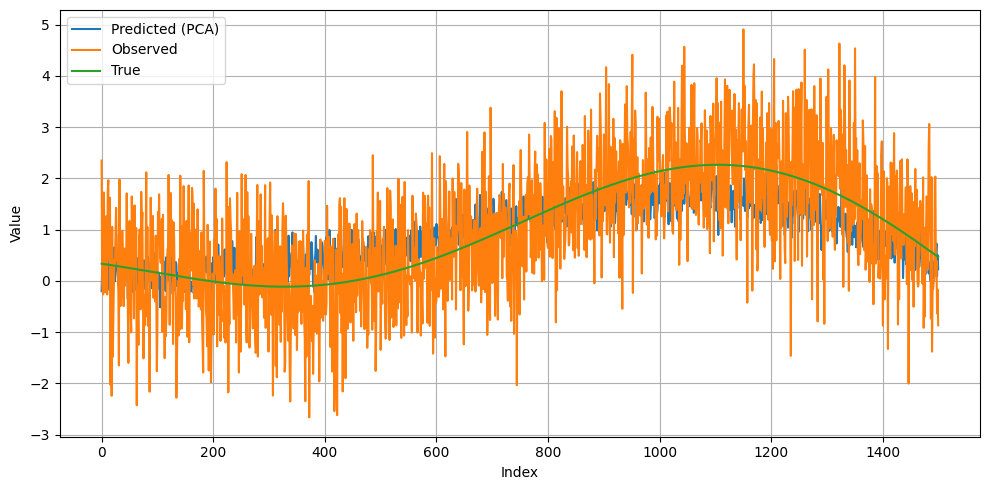

In [11]:
y_test_vector = y_test.data_matrix.squeeze()

i = 9

plt.figure(figsize=(10, 5))
plt.plot(y_preds_fpca.data_matrix.squeeze()[i,:], label='Predicted (FPCA)')
plt.plot(y_test_vector[i,:], label='observed')
plt.plot(y_true_test[i,:], label='True')


plt.title("Predicted vs True")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(y_preds_pca[i,:], label='Predicted (PCA)')
plt.plot(y_test_vector[i,:], label='Observed')
plt.plot(y_true_test[i,:], label='True')



plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


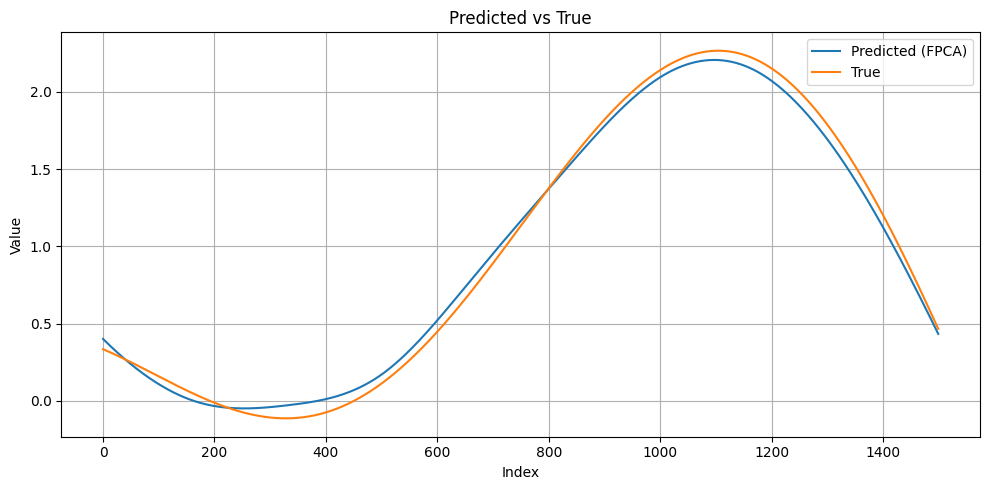

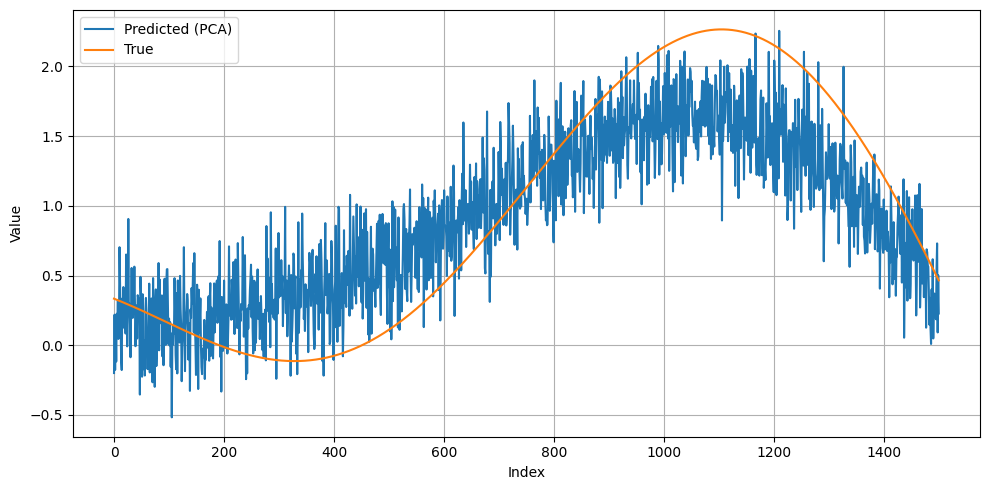

In [12]:
y_test_vector = y_true_test

plt.figure(figsize=(10, 5))
plt.plot(y_preds_fpca.data_matrix.squeeze()[i,:], label='Predicted (FPCA)')
#plt.plot(y_test_vector[i,:], label='observed')
plt.plot(y_test_vector[i,:], label='True')


plt.title("Predicted vs True")
plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(y_preds_pca[i,:], label='Predicted (PCA)')
#plt.plot(y_test_vector[i,:], label='Observed')
plt.plot(y_test_vector[i,:], label='True')


plt.xlabel("Index")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [13]:
r2   = r2_score(y_true_test, y_preds_pca)
mae  = mean_absolute_error(y_true_test, y_preds_pca)
mse = mean_squared_error(y_true_test, y_preds_pca)  
mape = mean_absolute_percentage_error(y_true_test, y_preds_pca)

print(f"PCA test metrics")
print(f"  R²     = {r2:.4f}")
print(f"  MAE    = {mae:.4f}")
print(f"  MSE    = {mse:.4f}")


r2   = r2_score(y_true_test, y_preds_fpca.data_matrix.squeeze())
mae  = mean_absolute_error(y_true_test, y_preds_fpca.data_matrix.squeeze())
mse = mean_squared_error(y_true_test, y_preds_fpca.data_matrix.squeeze())  
mape = mean_absolute_percentage_error(y_true_test, y_preds_fpca.data_matrix.squeeze())

print(f"FPCA test metrics")
print(f"  R²     = {r2:.4f}")
print(f"  MAE    = {mae:.4f}")
print(f"  MSE    = {mse:.4f}")


PCA test metrics
  R²     = 0.8016
  MAE    = 0.3522
  MSE    = 0.1911
FPCA test metrics
  R²     = 0.9810
  MAE    = 0.1074
  MSE    = 0.0178
